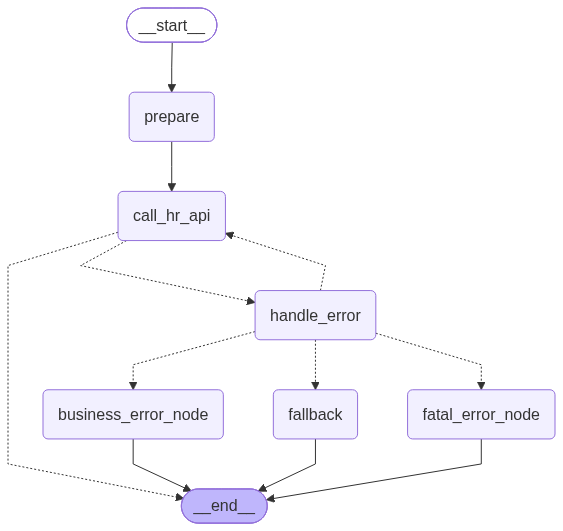


========== 场景 1: API 503 重试直到降级 (Fallback) ==========
[1. 准备阶段] 生成请求幂等键: 68ae9213-2b57-470a-8198-4f8bfe9c2d2a

[2. API 调用] 第 1 次请求 HR API...
  -> [HR API 响应] ❌ 503 Error
  -> [错误分析] 可重试错误(503)。重试 0/3。
  -> [依赖注入] 调用注入的 sleep_fn 等待 0.95 秒...
      (Mock Sleep: 假装休眠了 0.95 秒，瞬间醒来)

[2. API 调用] 第 2 次请求 HR API...
  -> [HR API 响应] ❌ 503 Error
  -> [错误分析] 可重试错误(503)。重试 1/3。
  -> [依赖注入] 调用注入的 sleep_fn 等待 0.08 秒...
      (Mock Sleep: 假装休眠了 0.08 秒，瞬间醒来)

[2. API 调用] 第 3 次请求 HR API...
  -> [HR API 响应] ❌ 503 Error
  -> [错误分析] 可重试错误(503)。重试 2/3。
  -> [依赖注入] 调用注入的 sleep_fn 等待 3.98 秒...
      (Mock Sleep: 假装休眠了 3.98 秒，瞬间醒来)

[2. API 调用] 第 4 次请求 HR API...
  -> [HR API 响应] ❌ 503 Error
  -> [错误分析] 可重试错误(503)，但重试预算 (3) 已耗尽！
[3A. Fallback] ⚠️ 重试耗尽降级：系统繁忙，已转入异步人工补偿队列。
【最终响应】: {'success': False, 'reason': 'System busy, queued for compensation'}

========== 场景 2: API 403 权限不足拦截 (Fatal) ==========
[1. 准备阶段] 生成请求幂等键: 81a6432b-ed12-4376-a5ae-54d5339ae54a

[2. API 调用] 第 1 次请求 HR API...
  -> [HR API 响应] ❌ 403 Er

In [3]:
import uuid
import time
import random
from typing_extensions import TypedDict
from IPython.display import Image, display

# LangGraph 相关
from langgraph.graph import START, END, StateGraph
from langchain_core.runnables import RunnableConfig

# ==========================================
# 1. 模拟系统配置与存储
# ==========================================
MAX_RETRIES = 3

# ==========================================
# 2. 定义状态 (新增 test_scenario_code 便于测试不同错误分支)
# ==========================================
class AgentState(TypedDict):
    employee_id: str
    amount: int
    idempotency_key: str
    retry_count: int
    status: str
    error_code: int
    error_msg: str
    result: dict
    test_scenario_code: int  # 仅作测试用，指定要模拟的 API 返回码

# ==========================================
# 3. 核心工具与算法
# ==========================================
def calculate_retry_delay(
    retry_count: int,
    base_delay: float = 1.0,
    max_delay: float = 8.0,
    random_fn=random.uniform,
) -> float:
    max_backoff = min(base_delay * (2 ** retry_count), max_delay)
    return random_fn(0, max_backoff)

# ==========================================
# 4. 图节点定义 (核心优化区)
# ==========================================
def prepare_operation_node(state: AgentState):
    operation_id = state.get("idempotency_key") or str(uuid.uuid4())
    print(f"[1. 准备阶段] 生成请求幂等键: {operation_id}")
    return {"idempotency_key": operation_id, "retry_count": 0, "status": "prepared"}

def call_hr_api_node(state: AgentState):
    """模拟 HR API 调用，根据 test_scenario_code 抛出不同错误"""
    attempt = state.get('retry_count', 0) + 1
    print(f"\n[2. API 调用] 第 {attempt} 次请求 HR API...")
    
    mock_code = state.get("test_scenario_code", 503)
    
    if mock_code == 200:
        print("  -> [HR API 响应] ✅ 200 OK")
        return {"status": "success", "result": {"success": True, "message": "Bonus applied."}}
    else:
        print(f"  -> [HR API 响应] ❌ {mock_code} Error")
        return {"status": "error", "error_code": mock_code, "error_msg": f"HTTP {mock_code}"}

# ✨ 优化 1: 通过 RunnableConfig 引入依赖注入
def handle_error_node(state: AgentState, config: RunnableConfig):
    """节点 3：错误分析与重试控制 (不直接写死 time.sleep)"""
    error_code = state.get("error_code")
    current_retry = state.get("retry_count", 0)
    
    # 从 config 中获取注入的 sleep_fn，如果没有则 fallback 到原生 time.sleep
    # 这样在测试环境可以注入一个 pass 或者是 mock，生产环境可以使用异步 sleep
    sleep_fn = config.get("configurable", {}).get("sleep_fn", time.sleep)

    # ✨ 优化 2: 细粒度的错误分类与路由
    if error_code in [503, 504, 429]:  # 场景 A: 瞬时故障/限流 -> 可重试
        if current_retry < MAX_RETRIES:
            delay = calculate_retry_delay(current_retry)
            print(f"  -> [错误分析] 可重试错误({error_code})。重试 {current_retry}/{MAX_RETRIES}。")
            print(f"  -> [依赖注入] 调用注入的 sleep_fn 等待 {delay:.2f} 秒...")
            
            sleep_fn(delay) # 使用注入的函数等待
            
            return {"status": "retry_able", "retry_count": current_retry + 1}
        else:
            print(f"  -> [错误分析] 可重试错误({error_code})，但重试预算 ({MAX_RETRIES}) 已耗尽！")
            return {"status": "retry_exhausted"}
            
    elif error_code in [400, 404, 422]: # 场景 B: 业务参数错误 -> 拒绝重试
        print(f"  -> [错误分析] 业务参数错误({error_code})，客户端需要修改请求。")
        return {"status": "business_failure"}
        
    elif error_code in [401, 403]:      # 场景 C: 致命错误/权限缺失 -> 立即阻断
        print(f"  -> [错误分析] 权限/认证拒绝({error_code})，触发安全告警。")
        return {"status": "fatal_failure"}
        
    else:
        print(f"  -> [错误分析] 未知异常({error_code})，进入兜底。")
        return {"status": "fatal_failure"}

# --- 以下为三个不同的终点节点 ---
def fallback_node(state: AgentState):
    print("[3A. Fallback] ⚠️ 重试耗尽降级：系统繁忙，已转入异步人工补偿队列。")
    return {"result": {"success": False, "reason": "System busy, queued for compensation"}}

def business_failure_node(state: AgentState):
    print("[3B. Business Final] 🚫 业务校验失败：请检查员工ID或金额额度限制。")
    return {"result": {"success": False, "reason": "Invalid business parameters"}}

def fatal_failure_node(state: AgentState):
    print("[3C. Fatal Final] 🚨 致命/越权错误：API Token 无效或无权操作该部门薪资！")
    return {"result": {"success": False, "reason": "Authorization failed or Fatal error"}}

# ==========================================
# 5. 图路由与构建
# ==========================================
def route_after_api(state: AgentState):
    return "handle_error" if state["status"] == "error" else END

def route_after_error(state: AgentState):
    status_map = {
        "retry_able": "call_hr_api",
        "retry_exhausted": "fallback",
        "business_failure": "business_error_node",
        "fatal_failure": "fatal_error_node"
    }
    return status_map[state["status"]]

builder = StateGraph(AgentState)
builder.add_node("prepare", prepare_operation_node)
builder.add_node("call_hr_api", call_hr_api_node)
builder.add_node("handle_error", handle_error_node)

# 注册三个不同的终态 Node
builder.add_node("fallback", fallback_node)
builder.add_node("business_error_node", business_failure_node)
builder.add_node("fatal_error_node", fatal_failure_node)

builder.add_edge(START, "prepare")
builder.add_edge("prepare", "call_hr_api")
builder.add_conditional_edges("call_hr_api", route_after_api, ["handle_error", END])
builder.add_conditional_edges("handle_error", route_after_error, [
    "call_hr_api", "fallback", "business_error_node", "fatal_error_node"
])

builder.add_edge("fallback", END)
builder.add_edge("business_error_node", END)
builder.add_edge("fatal_error_node", END)

graph = builder.compile()

# 显示新版图表 (在 Notebook 中运行能看到漂亮的分支)
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

# ==========================================
# 6. 使用依赖注入与不同场景进行测试
# ==========================================
if __name__ == "__main__":
    # 为了在 Notebook 中快速跑完，我们实现一个 Mock 的 Sleep，直接打印而不真正阻塞
    def fast_mock_sleep(seconds: float):
        print(f"      (Mock Sleep: 假装休眠了 {seconds:.2f} 秒，瞬间醒来)")

    # 包装依赖注入配置
    run_config = {"configurable": {"sleep_fn": fast_mock_sleep}}

    scenarios = [
        {"name": "场景 1: API 503 重试直到降级 (Fallback)", "code": 503},
        {"name": "场景 2: API 403 权限不足拦截 (Fatal)", "code": 403},
        {"name": "场景 3: API 400 传参错误 (Business)", "code": 400},
    ]

    for s in scenarios:
        print(f"\n{'='*10} {s['name']} {'='*10}")
        final_state = graph.invoke(
            {
                "employee_id": "E1001",
                "amount": 5000,
                "test_scenario_code": s["code"]
            },
            config=run_config  # 🎯 在这里将 mock_sleep 注入进去
        )
        print(f"【最终响应】: {final_state['result']}")